In [2]:
import sys

import numpy as np
import keras
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from tqdm.keras import TqdmCallback

from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical 

sys.path.insert(0, "/lustre/lrspec/users/4301/ABC-SN/code")
import data_degrading as dg
import abcsn_training
import abcsn_config
import data_preparation as dp
import preprocessing as pp


sys.path.insert(0, "/lustre/lrspec/users/4301/Milligan_ABC-SN/")
from plot_data import *
from process_data import *

2026-07-24 11:57:17.158760: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-07-24 11:57:17.908469: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-24 11:57:21.938533: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
file = "/lustre/lrspec/users/4301/Milligan_ABC-SN/data/full_preprocessed_dataframe.parquet"
master_df = pd.read_parquet(file)

In [4]:
# row normalized
# DASH Confusion Matrix
dash_matrix_row = np.array([
    [0.76, 0.09, 0.01, 0.14],
    [0.01, 0.67, 0.04, 0.28],
    [0.01, 0.21, 0.39,  0.39],
    [0.05, 0.76, 0.13, 0.06],
    [0.01, 0.64, 0.13,  0.21]
])

# NGSF Confusion Matrix
ngsf_matrix_row = np.array([
    [0.8, 0.02, 0.04, 0.14],
    [0.07, 0.52, 0.21, 0.20],
    [0.02, 0.03, 0.75, 0.19],
    [0.06, 0.02, 0.07, 0.85],
    [0.01, 0.1, 0.53, 0.36]
])

# SNID Confusion Matrix
snid_matrix_row = np.array([
    [0.66, 0.01, 0.0, 0.33],
    [0.11, 0.2, 0.0,  0.69],
    [0.09, 0.08, 0.17, 0.66],
    [0.0, 0.0, 0.0, 0.99],
    [0.06, 0.02, 0.0, 0.92]
])


# column normalized 
# DASH Confusion Matrix
dash_matrix_col = np.array([
    [0.98, 0.24, 0.08, 0.0, 0.0, 0.44],
    [0.0, 0.22, 0.03, 0.0, 0.0, 0.11],
    [0.01, 0.19, 0.77, 0.0, 0.0, 0.41],
    [0.01, 0.32, 0.11, 0.0, 0.0, 0.03],
    [0.0, 0.03, 0.01, 0.0, 0.0, 0.01]
])

# NGSF Confusion Matrix
ngsf_matrix_col = np.array([
    [0.97, 0.22, 0.11, 0.24, 0.44, 0.8],
    [0.01, 0.61, 0.08, 0.05, 0.16, 0.08],
    [0.01, 0.11, 0.75, 0.17, 0.36, 0.13],
    [0.01, 0.04, 0.03, 0.51, 0.0, 0.0],
    [0.0, 0.02, 0.03, 0.02, 0.03, 0.0]
])

# SNID Confusion Matrix
snid_matrix_col = np.array([
    [0.94, 0.22, 0.0, 0.0, 0.0, 0.41],
    [0.02, 0.37, 0.01, 0.0, 0.0, 0.11],
    [0.04, 0.4, 0.99, 0.0, 0.0, 0.27],
    [0.0, 0.01, 0.0, 0.0, 0.0, 0.19],
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.02]
])

In [5]:
abcsn_raw = np.array([[2084,  342,   75,    0,    0,    0],
       [  60,  211,   28,    0,    0,    0],
       [  62,  186,  562,    0,    0,    0],
       [  41,  280,   58,    0,    0,    0],
       [   7,   29,    8,    0,    0,    0],
       [   0,    0,    0,    0,    0,    0]])

In [6]:
abcsn_row = abcsn_raw.astype("float") / np.nansum(abcsn_raw, axis=1)[:, np.newaxis]
abcsn_row

/tmp/ipykernel_6991/1368207856.py:1: RuntimeWarning: invalid value encountered in divide
  abcsn_row = abcsn_raw.astype("float") / np.nansum(abcsn_raw, axis=1)[:, np.newaxis]


array([[0.83326669, 0.1367453 , 0.029988  , 0.        , 0.        ,
        0.        ],
       [0.2006689 , 0.70568562, 0.09364548, 0.        , 0.        ,
        0.        ],
       [0.07654321, 0.22962963, 0.69382716, 0.        , 0.        ,
        0.        ],
       [0.10817942, 0.73878628, 0.1530343 , 0.        , 0.        ,
        0.        ],
       [0.15909091, 0.65909091, 0.18181818, 0.        , 0.        ,
        0.        ],
       [       nan,        nan,        nan,        nan,        nan,
               nan]])

In [16]:
def plot_cm(ax, cm, classes, title=False, normalize=True, title_fontsize=12, number_fontsize=11):
    ''' Code sent to me by Fed created by Willow to plot confusion matrix
    '''
    # I removed the variable R as it was not used

    textargs = {"fontname": "Serif"}

    # Normalize confusion matrix and set image parameters
    if normalize:
        cm = cm.astype("float") / np.nansum(cm, axis=1)[:, np.newaxis]
    else:
        cm = cm.astype("float")
    if cm.shape[0] == cm.shape[1]:
        off_diag = ~np.eye(cm.shape[0], dtype=bool)
        cm[off_diag] *= -1
    else:
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                if i!=j:
                    cm[i,j] *= -1
    
    if normalize:
        im = ax.imshow(cm, interpolation="none", cmap="RdBu", vmin=-1, vmax=1)
    else:
        im = ax.imshow(cm, interpolation="none", cmap="RdBu", vmin=-1, vmax=1)

    # if normalize:
    #     cbticks = np.linspace(-1, 1, num=9)
    #     cbticklabels = ["100%", "75%", "50%", "25%", "0%", "25%", "50%", "75%", "100%"]
    #     cb = plt.colorbar(im, shrink=0.82)
    #     cb.set_ticks(cbticks, labels=cbticklabels, fontsize= 12, **textargs)
    # else:
    #     cbticks = np.linspace(-1, 1, num=9)
    #     cbticklabels = ["100%", "75%", "50%", "25%", "0%", "25%", "50%", "75%", "100%"]
    #     cb = plt.colorbar(im, shrink=0.82)
    #     cb.set_ticks(cbticks, labels=cbticklabels, fontsize= 12, **textargs)

    if title:
        ax.set_title(title, **textargs, fontsize=title_fontsize)
    tick_marks = np.arange(len(classes)+1)
    tick_labels = [ "" for i in range(len(classes)+1)]
    ax.set_xticks(tick_marks, tick_labels)
    ax.set_yticks(tick_marks[:len(classes)], tick_labels[:len(classes)])
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = np.abs(cm[i, j])
            if val == 0:
                text = ""
            elif np.isnan(val):
                text = "" # Handle NaN values
            elif val == 1:
                text = "100"
            else:
                text = f"{val*100:.0f}%"
            color = "w" if val >= 0.50 else "k"
            ax.text(
                j, i, text,
                ha="center", va="center",
                c=color, **textargs, fontsize=number_fontsize,
            )
    # ax.set_ylabel("True label", fontsize=20, **textargs)
    # ax.set_xlabel("Predicted label", fontsize=20, **textargs)

    return fig

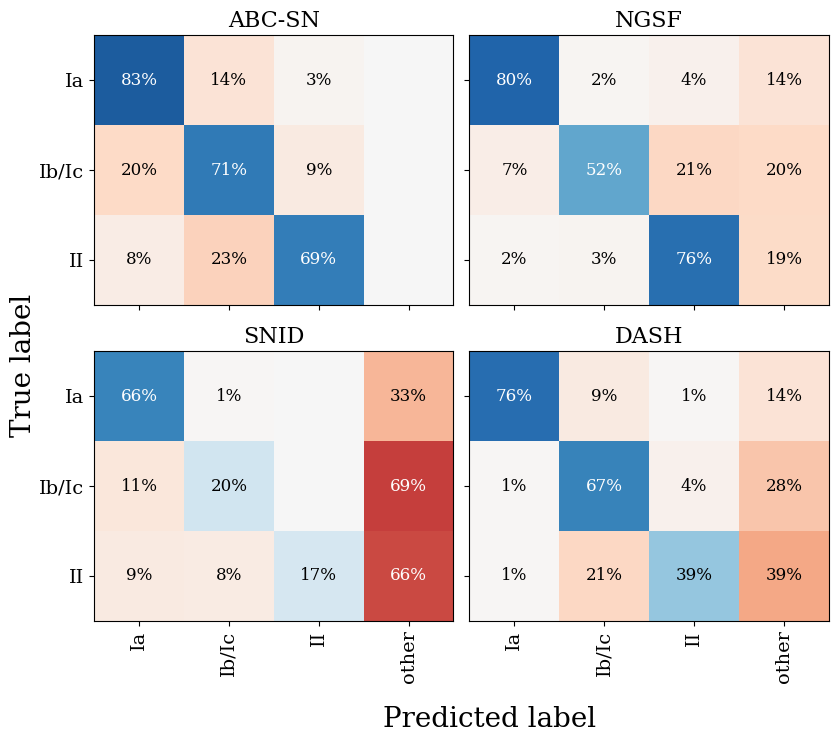

In [18]:
fig, ax = plt.subplots(figsize=(10,7.5), nrows=2, ncols=2)
textargs = {"fontname": "Serif"}

classes = ["Ia", "Ib/Ic", "II", "other"]
num_class = 3
normalize = True
plot_cm(ax[0,1], ngsf_matrix_row[:num_class, :num_class +1], classes[:num_class], normalize = normalize, title_fontsize = 16, number_fontsize= 12, title="NGSF")
plot_cm(ax[1,1], dash_matrix_row[:num_class, :num_class+1], classes[:num_class], normalize = normalize, title_fontsize = 16, number_fontsize= 12, title="DASH")
plot_cm(ax[1,0], snid_matrix_row[:num_class, :num_class+1], classes[:num_class], normalize = normalize, title_fontsize = 16,  number_fontsize= 12, title="SNID")
plot_cm(ax[0,0], abcsn_row[:num_class, :num_class+1], classes[:num_class], normalize = normalize, title_fontsize = 16, number_fontsize= 12, title="ABC-SN")

tick_marks_y = np.arange(num_class)
tick_marks_x = np.arange(num_class+1)
ax[1,1].set_xticks(tick_marks_x, classes[:num_class+1], rotation=90, **textargs,  fontsize= 14)
ax[1,0].set_xticks(tick_marks_x, classes[:num_class+1], rotation=90,  **textargs, fontsize= 14)
ax[0,0].set_yticks(tick_marks_y, classes[:num_class],  **textargs, fontsize= 14)
ax[1,0].set_yticks(tick_marks_y, classes[:num_class], **textargs,  fontsize= 14)

# 1. Create a ScalarMappable to define the colormap and limits (since we don't have one single 'cm' variable)
norm = plt.Normalize(vmin=-1, vmax=1)
sm = plt.cm.ScalarMappable(cmap="RdBu", norm=norm)
sm._A = [] # Dummy array needed for the mappable

# 2. Adjust layout to make space on the right for the colorbar
fig.subplots_adjust(right=0.85) # Leaves 15% empty space on the right

# # 3. Add the colorbar targeting ALL 4 axes
# cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7]) # [left, bottom, width, height] - positions it vertically
# cb = fig.colorbar(sm, cax=cbar_ax)

# # 4. Set the ticks and labels
# cbticks = np.linspace(-1, 1, num=9)
# cbticklabels = ["100%", "75%", "50%", "25%", "0%", "25%", "50%", "75%", "100%"]
# cb.set_ticks(cbticks)
# cb.set_ticklabels(cbticklabels, fontsize=12, fontname="Serif")


fig.supxlabel("Predicted label", fontsize=20, **textargs)
fig.supylabel("True label", fontsize=20, **textargs)
fig.tight_layout(rect=[0, 0, 0.85, 1], pad = 0.8, h_pad=0) 
plt.show()

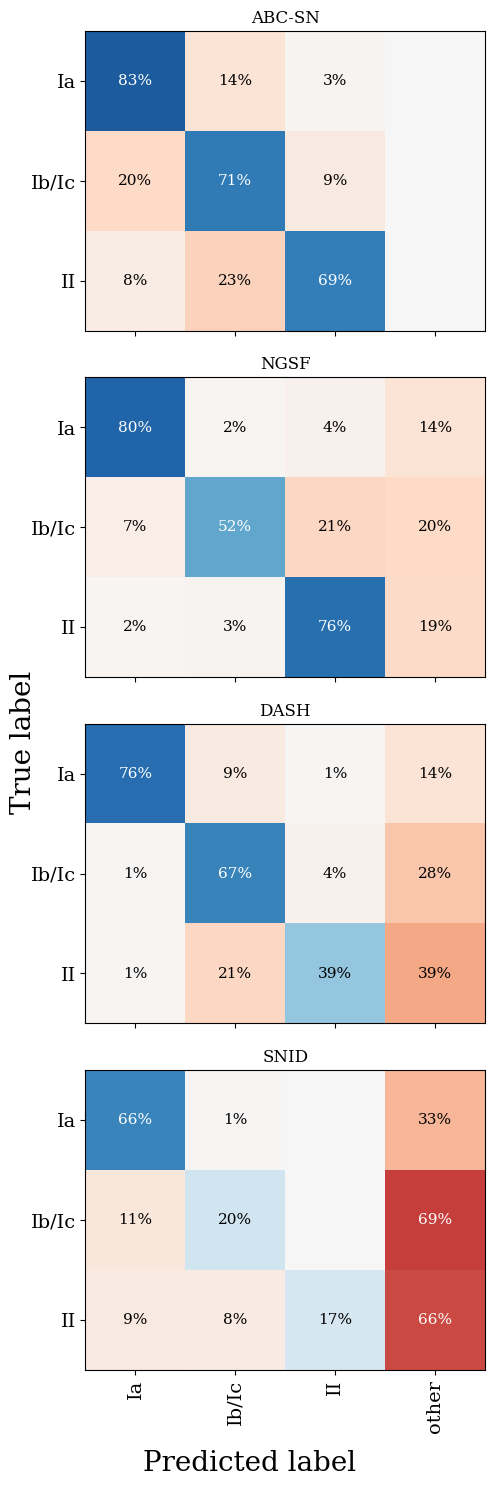

In [9]:
fig, ax = plt.subplots(figsize=(5,15), nrows=4, ncols=1)
textargs = {"fontname": "Serif"}

classes = ["Ia", "Ib/Ic", "II", "other"]
num_class = 3
normalize = True
plot_cm(ax[1], ngsf_matrix_row[:num_class, :num_class +1], classes[:num_class], normalize = normalize, title="NGSF")
plot_cm(ax[2], dash_matrix_row[:num_class, :num_class+1], classes[:num_class], normalize = normalize, title="DASH")
plot_cm(ax[3], snid_matrix_row[:num_class, :num_class+1], classes[:num_class], normalize = normalize, title="SNID")
plot_cm(ax[0], abcsn_row[:num_class, :num_class+1], classes[:num_class], normalize = normalize, title="ABC-SN")

tick_marks_y = np.arange(num_class)
tick_marks_x = np.arange(num_class+1)
ax[3].set_xticks(tick_marks_x, classes[:num_class+1], rotation=90, **textargs,  fontsize= 14)
# ax[1,0].set_xticks(tick_marks_x, classes[:num_class+1], rotation=90,  **textargs, fontsize= 14)
ax[0].set_yticks(tick_marks_y, classes[:num_class], **textargs,  fontsize= 14)
ax[1].set_yticks(tick_marks_y, classes[:num_class],  **textargs, fontsize= 14)
ax[2].set_yticks(tick_marks_y, classes[:num_class], **textargs,  fontsize= 14)
ax[3].set_yticks(tick_marks_y, classes[:num_class], **textargs,  fontsize= 14)

# 1. Create a ScalarMappable to define the colormap and limits (since we don't have one single 'cm' variable)
norm = plt.Normalize(vmin=-1, vmax=1)
sm = plt.cm.ScalarMappable(cmap="RdBu", norm=norm)
sm._A = [] # Dummy array needed for the mappable

# # 2. Adjust layout to make space on the right for the colorbar
# fig.subplots_adjust(right=0.85) # Leaves 15% empty space on the right

# # 3. Add the colorbar targeting ALL 4 axes
# cbar_ax = fig.add_axes([0.88, 0.15, 0.03, 0.7]) # [left, bottom, width, height] - positions it vertically
# cb = fig.colorbar(sm, cax=cbar_ax)

# # 4. Set the ticks and labels
# cbticks = np.linspace(-1, 1, num=9)
# cbticklabels = ["100%", "75%", "50%", "25%", "0%", "25%", "50%", "75%", "100%"]
# cb.set_ticks(cbticks)
# cb.set_ticklabels(cbticklabels, fontsize=12, fontname="Serif")


fig.supxlabel("Predicted label", fontsize=20, **textargs)
fig.supylabel("True label", fontsize=20, **textargs)
# fig.tight_layout(rect=[0, 0, 0.85, 1], pad = 0.8, h_pad=0) 
fig.tight_layout()
plt.show()